# 03 - Arquitectura de línea de base

**Proyecto Deep Learning: Detección de Imágenes Generadas por IA (CIFAKE)**

En este notebook se construye, compila y entrena el modelo **baseline**: una Red Neuronal Convolucional (CNN) secuencial. Se entrena durante **10 épocas**, se grafican las curvas de aprendizaje y finalmente se **guarda el modelo** para usarlo en el notebook de evaluación (`04`).

## 1. Instalar e importar librerías

In [1]:
!pip install -q kagglehub

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 2. Descargar, cargar y preprocesar los datos

Se incluyen los pasos de ingesta y normalización para que el notebook sea autónomo.

In [3]:
import kagglehub

# Descarga el dataset CIFAKE desde Kaggle (queda en cache la primera vez)
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print('Ruta del dataset:', path)

Ruta del dataset: C:\Users\Anonymous\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [4]:
train_path = Path(path) / 'train'
test_path = Path(path) / 'test'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path, image_size=(32, 32), batch_size=32,
    class_names=['FAKE', 'REAL'], label_mode='binary')

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, image_size=(32, 32), batch_size=32,
    class_names=['FAKE', 'REAL'], label_mode='binary')

print('Datos cargados')

Found 100000 files belonging to 2 classes.


Found 20000 files belonging to 2 classes.


Datos cargados


In [5]:
def normalize(images, labels):
    return images / 255.0, labels

train_ds = train_ds.map(normalize).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize).cache().prefetch(tf.data.AUTOTUNE)

print('Datos normalizados')

Datos normalizados


## 3. Definir la arquitectura CNN (baseline)

Arquitectura secuencial:
- **3 bloques convolucionales** (`Conv2D` con 32, 64 y 128 filtros) que extraen patrones espaciales (bordes, texturas).
- **`MaxPooling2D`** para reducir la dimensionalidad y lograr invariancia a la traslación.
- **`Dropout(0.5)`** como regularización para mitigar el sobreajuste.
- Capa **`Dense` final con activación `sigmoid`** para la clasificación binaria.
- Función de pérdida: **`binary_crossentropy`** y optimizador **Adam**.

In [6]:
model = keras.Sequential([
    keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\Anonymous\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenar el modelo (10 épocas)

In [7]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)
print('\nEntrenamiento completado')

Epoch 1/10


   1/3125 ━━━━━━━━━━━━━━━━━━━━ 1:10:54 1s/step - accuracy: 0.5938 - loss: 0.6803

   2/3125 ━━━━━━━━━━━━━━━━━━━━ 2:37 51ms/step - accuracy: 0.5625 - loss: 0.6802 

   4/3125 ━━━━━━━━━━━━━━━━━━━━ 2:11 42ms/step - accuracy: 0.5658 - loss: 0.6803

   5/3125 ━━━━━━━━━━━━━━━━━━━━ 2:23 46ms/step - accuracy: 0.5664 - loss: 0.6810

...

3111/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9618 - loss: 0.1005

3117/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9618 - loss: 0.1005

3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9617 - loss: 0.1005

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.9612 - loss: 0.1004 - val_accuracy: 0.9276 - val_loss: 0.2199



Entrenamiento completado


## 5. Curvas de aprendizaje

Se grafica la evolución de la exactitud (accuracy) y la pérdida (loss) en entrenamiento y validación.

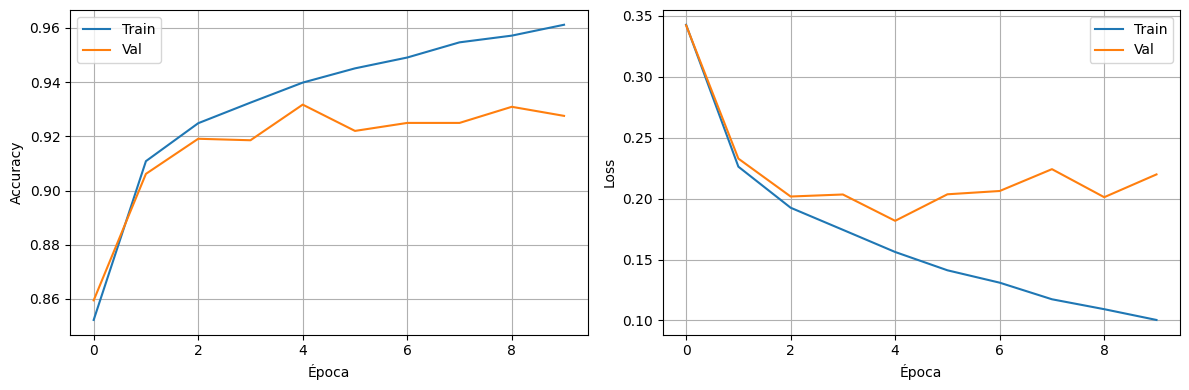

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Época')
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

## 6. Evaluación rápida sobre el conjunto de prueba

In [9]:
loss, accuracy = model.evaluate(test_ds)
print(f'\nPérdida: {loss:.4f}')
print(f'Exactitud: {accuracy:.4f} ({accuracy*100:.2f}%)')

  1/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9062 - loss: 0.4719

 14/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9350 - loss: 0.2231

 28/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9346 - loss: 0.2018

 41/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9355 - loss: 0.1908

 55/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9358 - loss: 0.1837

...

590/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9293 - loss: 0.2083

604/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9293 - loss: 0.2086

618/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9292 - loss: 0.2089

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9276 - loss: 0.2199



Pérdida: 0.2199
Exactitud: 0.9276 (92.76%)


## 7. Guardar el modelo entrenado

Se guarda el modelo en formato `.keras` para reutilizarlo en el notebook `04 - evaluacion_y_resultados`.

In [10]:
model.save('modelo_cifake.keras')
print('Modelo guardado como modelo_cifake.keras')

Modelo guardado como modelo_cifake.keras
